In [75]:
import pandas as pd
import numpy as np


df = pd.read_csv("suburb-silo-data.csv", parse_dates=["date"])



In [76]:
df_weather = df.copy()
df_weather = df_weather[['Suburb','date','max_temp','min_temp','vp','radiation']]
df_weather['year'] = df_weather['date'].dt.year
df_weather['month'] = df_weather['date'].dt.month



In [89]:
df_weather["vp_kpa"] = df_weather["vp"] / 10.0
df_weather['Q_net'] = (df_weather['radiation'] * 1000000 / (12 * 3600)) * 0.15

df_weather['apparent_temp_advanced'] = (
    df_weather['max_temp'] +
    (0.348 * df_weather['vp']) +
    (0.70 * df_weather['Q_net'] / 10) -
    4.25
)

df_weather["apparent_temp"] = -1.3 + (0.92 * df_weather["max_temp"]) + (2.2 * df_weather["vp_kpa"])
df_weather.head()


,Suburb,date,max_temp,min_temp,vp,radiation,year,month,vp_kpa,apparent_temp,heat_danger_level,is_dangerous_day,Q_watts,apparent_temp_advanced,Q_net
0,ACACIA RIDGE,2016-01-01,30.1,17.2,15.7,24.8,2016,1,1.57,29.846,Normal,0,574.074074,37.341378,86.111111
1,ACACIA RIDGE,2016-01-02,30.2,15.7,15.0,27.9,2016,1,1.50,29.784,Normal,0,645.833333,37.951250,96.875000
2,ACACIA RIDGE,2016-01-03,27.2,20.1,18.9,11.7,2016,1,1.89,27.882,Normal,0,270.833333,32.370950,40.625000
3,ACACIA RIDGE,2016-01-04,27.6,18.1,20.2,13.4,2016,1,2.02,28.536,Normal,0,310.185185,33.636544,46.527778
4,ACACIA RIDGE,2016-01-05,25.5,20.4,23.5,3.9,2016,1,2.35,27.330,Normal,0,90.277778,30.375917,13.541667


In [78]:
radiation_threshold = df_weather["radiation"].quantile(0.75)
conditions = [
    (df_weather["apparent_temp"] >= 39), # Extremely Dangerous
    (df_weather["apparent_temp"] >= 32) & (df_weather["radiation"] >= radiation_threshold), # High Risk
    (df_weather["apparent_temp"] >= 32) & (df_weather["min_temp"] >= 24) # Fatigue Risk
]
values = ["Extreme", "High", "Caution"]

In [79]:
df_weather["heat_danger_level"] = np.select(conditions, values, default="Normal")
df_weather["is_dangerous_day"] = (df_weather["heat_danger_level"] != "Normal").astype(int)


In [80]:
summary = df_weather.groupby("Suburb").agg({
    "is_dangerous_day": "sum",
    "apparent_temp": "max",
    "radiation": "mean"
}).sort_values("is_dangerous_day", ascending=False)
summary

,is_dangerous_day,apparent_temp,radiation
Suburb,,,
CHUWAR,528,42.804,18.437676
KARANA DOWNS,518,42.322,18.395223
MOUNT CROSBY,518,42.322,18.395223
MOGGILL,508,42.022,18.381895
WACOL,508,42.022,18.381895
...,...,...,...
BANKS CREEK,245,39.806,17.968648
BULWER,215,39.138,18.729479
ENGLAND CREEK,203,39.372,17.685695


In [81]:
yearly_summary = df_weather.groupby("year").agg({
    "is_dangerous_day": "sum",
    "apparent_temp": ["mean", "max"],
    "max_temp": "mean",
    "radiation": "mean"
}).reset_index()
yearly_summary

year is_dangerous_day apparent_temp           max_temp  radiation
                      sum          mean     max       mean       mean
0   2016             4941     27.107833  39.456  26.792018  18.202142
1   2017             9052     27.190560  42.804  26.835568  18.611169
2   2018             7365     26.929039  40.060  26.609627  18.627336
3   2019            10101     27.539280  42.196  27.335027  19.418234
4   2020             8229     27.031129  38.926  26.624978  18.399287
5   2021             3740     26.390618  37.564  25.945373  17.865046
6   2022             3514     25.831661  37.838  25.335741  17.294992
7   2023             7035     27.182037  39.632  26.860752  18.864659
8   2024             8280     27.472695  40.484  26.572770  17.955258
9   2025             6658     27.277912  40.540  26.607634  18.724378
10  2026             1864     32.052961  40.292  30.709310  23.479174

/var/folders/mr/tkk4szdj1xdb_wyds6ngx9v00000gn/T/ipykernel_14711/629578819.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly_data, x='year', y='is_dangerous_day', palette='Reds_d')


Text(0.5, 0, 'Year')

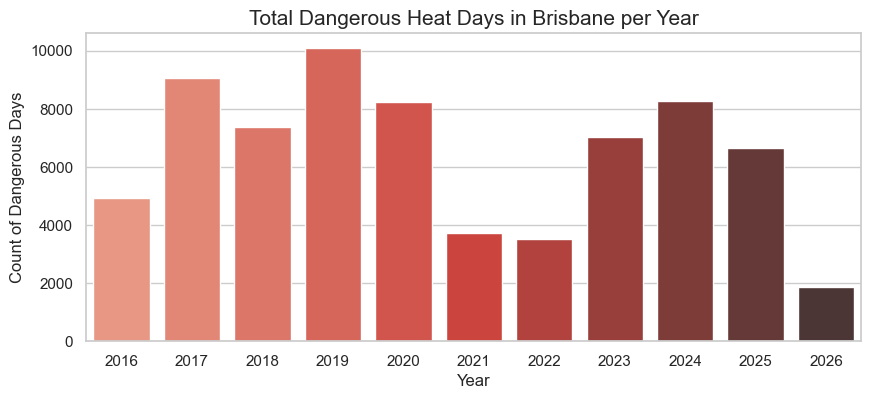

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 4]

yearly_data = df_weather.groupby('year')['is_dangerous_day'].sum().reset_index()
plt.figure()
sns.barplot(data=yearly_data, x='year', y='is_dangerous_day', palette='Reds_d')
plt.title('Total Dangerous Heat Days in Brisbane per Year', fontsize=15)
plt.ylabel('Count of Dangerous Days')
plt.xlabel('Year')

/var/folders/mr/tkk4szdj1xdb_wyds6ngx9v00000gn/T/ipykernel_14711/3038375245.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=suburb_data, x='is_dangerous_day', y='Suburb', palette='YlOrRd_r')


Text(0.5, 0, 'Total Dangerous Days (Cumulative)')

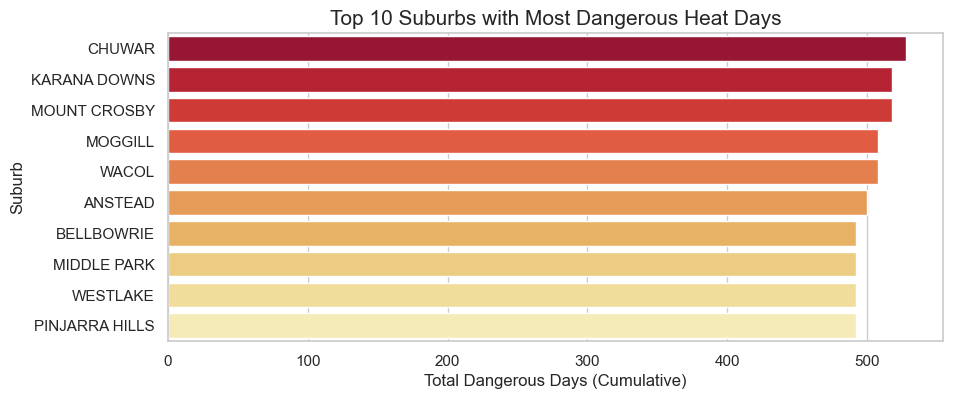

In [83]:
suburb_data = df_weather.groupby('Suburb')['is_dangerous_day'].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure()
sns.barplot(data=suburb_data, x='is_dangerous_day', y='Suburb', palette='YlOrRd_r')
plt.title('Top 10 Suburbs with Most Dangerous Heat Days', fontsize=15)
plt.xlabel('Total Dangerous Days (Cumulative)')

In [84]:
monthly_summary = df_weather.groupby('month')['is_dangerous_day'].sum().reset_index()
monthly_summary = monthly_summary.sort_values('is_dangerous_day', ascending=False)
print("─── Months with most Dangerous Heat Days ───")
print(monthly_summary[['month', 'is_dangerous_day']])

─── Months with most Dangerous Heat Days ───
    month  is_dangerous_day
0       1             23232
1       2             17705
11     12             15033
10     11              7635
2       3              3966
9      10              2805
8       9               403
3       4                 0
4       5                 0
5       6                 0
6       7                 0
7       8                 0


/var/folders/mr/tkk4szdj1xdb_wyds6ngx9v00000gn/T/ipykernel_14711/2837148228.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


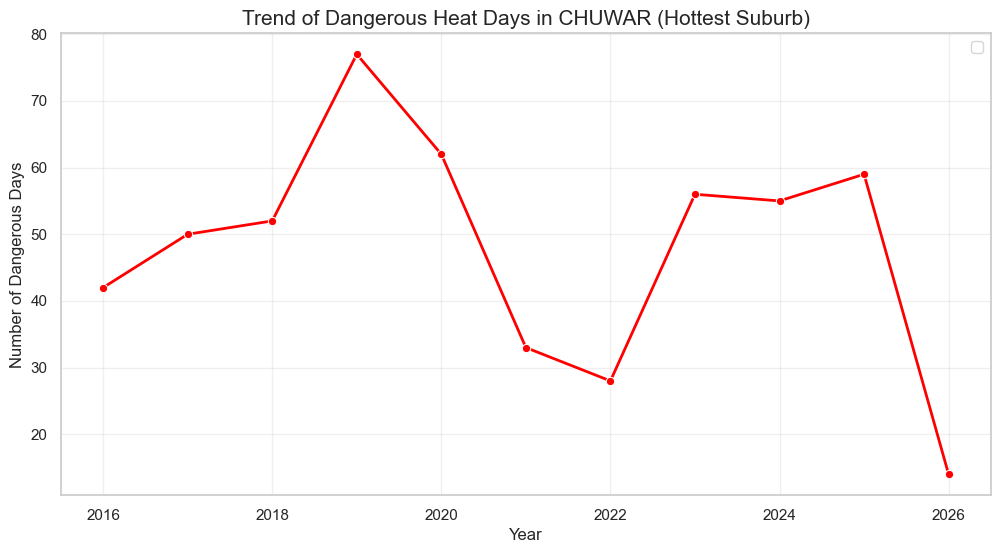

In [ ]:
hottest_suburb_name = df_weather.groupby('Suburb')['is_dangerous_day'].sum().idxmax()
hottest_suburb_data = df_weather[df_weather['Suburb'] == hottest_suburb_name]


yearly_hottest = hottest_suburb_data.groupby('year')['is_dangerous_day'].sum().reset_index()


plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_hottest, x='year', y='is_dangerous_day', marker='o', color='red', linewidth=2)

plt.title(f'Trend of Dangerous Heat Days in {hottest_suburb_name} (Hottest Suburb)', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Number of Dangerous Days')
plt.grid(True, alpha=0.3)
plt.legend()